# 01. Understanding the inputs to Stage 1

This notebook explains the real inputs that pySTAMPS Stage 1 needs.

The goal is simple: before you run Stage 1, you should be able to answer three questions without reading source code:

- What arrays does Stage 1 need?
- Where do those arrays usually come from in a StaMPS-style dataset?
- Does my dataset look internally consistent enough for Stage 1 to succeed?

## Stage 1 in plain language

Stage 1 is the ingestion and organization step. It takes raw persistent-scatterer candidate data and turns it into structured outputs that the rest of the pipeline can use safely.

You do not need SAR expertise to follow this notebook. A practical mental model is enough:

- a **candidate** is one point that may behave like a stable radar scatterer
- a **patch** is one spatial tile of the dataset
- an **interferogram** is one phase-difference product between radar acquisitions
- Stage 1 reads raw candidate tables and phase values, checks that they agree, then writes organized outputs such as `ps1.mat`, `ph1.mat`, and `bp1.mat`

## The key idea: arrays are the contract, files are only one carrier

For users, this is the most important design idea in pySTAMPS:

- the pipeline really needs **arrays and scalars**
- text files, MAT files, NPY files, HDF5 files, pickle files, or in-memory objects are only **storage/transport formats**
- if the values, shapes, ordering, and dtypes are correct, the carrier format is secondary

So this notebook separates two views:

1. the **logical Stage-1 contract**: the arrays the algorithm needs
2. the **observed dataset inventory**: the concrete files found in the bundled example dataset

That separation is intentional. It makes the package easier to understand and harder to misuse.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

from pystamps.input_contracts import describe_stage1_snap2stamps_flow, describe_stage_inputs
from pystamps.notebooks import inspect_stage1_inputs

plt.style.use('seaborn-v0_8-whitegrid')
np.set_printoptions(suppress=True, precision=4)
pd.set_option('display.max_colwidth', 120)

DATASET = Path('inputs_and_outputs') / 'InSAR_dataset_test'
PATCH_NAME = 'PATCH_1'
DATASET_LABEL = DATASET.name

STAGE1_CONTRACT = describe_stage_inputs(1)[0]
ALL_STAGE_CONTRACTS = describe_stage_inputs('all')
SUMMARY = inspect_stage1_inputs(DATASET, patch_name=PATCH_NAME)

print(f'Dataset: {DATASET_LABEL}')
print(f'Patch:   {PATCH_NAME}')
print(f"Metadata mode: {SUMMARY['metadata_mode']}")
print(f"Warnings raised by package checks: {len(SUMMARY['warnings'])}")

Dataset: InSAR_dataset_test
Patch:   PATCH_1
Metadata mode: derived from diff0 base files and rslc metadata at stage-1 runtime
Warnings raised by package checks: 1


## Logical Stage-1 contract

The next table is the cleanest definition of what Stage 1 needs.

Read it as an API contract:

- **array_name** is the logical object the algorithm expects
- **shape_hint** is the expected dimensionality
- **meaning** is the semantic role of that object
- **common_sources** gives typical storage formats, but those are examples, not the contract itself

If you have these arrays in memory with the correct meaning and shape, Stage 1 is conceptually ready to run.

In [2]:
contract_df = pd.DataFrame(STAGE1_CONTRACT['inputs'])
display(contract_df)

,logical_input,array_name,shape_hint,meaning,common_sources
0,candidate indices,ij,"[n_candidates, 3]","candidate id, azimuth row, range column","pscands.1.ij, npy, h5, pickle, in-memory ndarray"
1,complex candidate phase stack,ph,"[n_candidates, n_ifg]",one complex phase value per candidate and interferogram,"pscands.1.ph, mat, npy, h5, pickle, in-memory ndarray"
2,candidate longitude/latitude,lonlat,"[n_candidates, 2]",longitude and latitude for each candidate,"pscands.1.ll, npy, h5, pickle, in-memory ndarray"
3,patch width,width,scalar,range width of the patch raster,"width.txt, config, h5 attribute, in-memory scalar"
4,patch length,length,scalar,azimuth length of the patch raster,"len.txt, config, h5 attribute, in-memory scalar"
5,acquisition days,day,[n_ifg],slave acquisition dates used to build the time axis,day.1.in or values derived from diff0/rslc metadata
6,master acquisition day,master_day,scalar,the master date inserted into the image timeline,master_day.1.in or values derived from diff0/rslc metadata
7,perpendicular baseline summary,bperp,[n_ifg],one perpendicular baseline value per interferogram,bperp.1.in or values derived from diff0/rslc metadata
8,optional stability metric,D_A,[n_candidates],candidate stability values for QC and side outputs,"pscands.1.da, npy, h5, pickle, in-memory ndarray"
9,optional height prior,hgt,[n_candidates],per-candidate height values when available,"pscands.1.hgt, npy, h5, pickle, in-memory ndarray"


## Whole-pipeline view

This notebook focuses on Stage 1, but the CLI can describe all pipeline stages.

The compact table below is useful when you want to see how the pipeline progresses from raw candidate ingestion to final filtered outputs.

In [3]:
all_stages_df = pd.DataFrame([
    {'stage': item['stage'], 'title': item['title']}
    for item in ALL_STAGE_CONTRACTS
])
display(all_stages_df)

,stage,title
0,1,Load and organize raw candidate inputs
1,2,Estimate phase model and coherence per patch
2,3,Select persistent scatterers
3,4,Weed noisy or redundant candidates
4,5,Merge patch outputs into one dataset view
5,6,Unwrap the merged phase products
6,7,Estimate slow trends and correction terms
7,8,Apply final space-time filtering


## Where these Stage-1 inputs come from in the SNAP to StaMPS workflow

Stage 1 does not create its raw inputs from the original SAR scenes. Those files are produced upstream by the SNAP-to-StaMPS preprocessing workflow.

Upstream context:

- the StaMPS project lists SNAP as one of the supported preprocessors
- the SNAP2StaMPS repository provides the concrete SNAP-side step sequence
- in that workflow, the final export step writes the StaMPS-compatible dataset that pySTAMPS Stage 1 reads

For Sentinel-1 TOPSAR, the SNAP2StaMPS README describes a step-by-step chain ending with `topsar_step_5_stamps_export_multiIW.py`. That export stage is the practical handoff point between SNAP products and the StaMPS-style patch files used here.

So the correct mental model is:

1. SNAP2StaMPS prepares and exports a StaMPS-compatible dataset
2. pySTAMPS Stage 1 ingests that exported dataset
3. pySTAMPS writes `ps1.mat`, `ph1.mat`, `bp1.mat`, and related MATLAB files for Stage 2

Primary upstream references:

- StaMPS repository: https://github.com/dbekaert/StaMPS
- SNAP2StaMPS repository: https://github.com/mdelgadoblasco/snap2stamps

In [4]:
snap2stamps_flow_df = pd.DataFrame(describe_stage1_snap2stamps_flow())
display(snap2stamps_flow_df)

,upstream_stage,tool_or_script,what_happens,why_stage1_cares
0,stack preparation,auto_run.py or the step-by-step SNAP2StaMPS workflow,The SNAP-side workflow prepares the Sentinel-1 or stripmap stack and optionally chooses the master scene.,Stage 1 later needs a stable master/slave chronology and a consistent image stack.
1,scene splitting,topsar_step_1_splitting_master_multi_IW.py and topsar_step_2_splitting_secondaries.py,The selected bursts or subswaths are split into the analysis area so later products refer to the same footprint.,The patch geometry and candidate coordinates must refer to one common spatial subset.
2,coregistration and interferogram generation,topsar_step_3_coreg_ifg_topsar_smart.py,Secondary scenes are coregistered to the master and interferograms are formed.,The complex phase stack and the associated acquisition/baseline metadata originate from this interferometric stack.
3,StaMPS export,topsar_step_5_stamps_export_multiIW.py or stripmap_step_5_stamps_export.py,SNAP2StaMPS exports the processed SNAP products into a StaMPS-compatible dataset tree.,"This export step is what creates the patch-level Stage-1 raw inputs such as pscands.1.ij, pscands.1.ph, pscands.1.ll..."


## What the package checks automatically

The next tables are generated by package-side inspection code, not handwritten notebook logic.

This is important because users should not have to infer data consistency by eye. The package should check the obvious failure modes early and say so clearly.

The consistency table answers questions such as:

- do the candidate tables have the same number of rows?
- does the phase stack have the same number of interferograms as the time and baseline metadata?
- are some inputs missing but recoverable at runtime?

The warning table summarizes concrete issues or limitations.

In [5]:
consistency_df = pd.DataFrame(SUMMARY['consistency_rows'])
warnings_df = pd.DataFrame({'warning': SUMMARY['warnings']})

display(consistency_df)
if warnings_df.empty:
    display(Markdown('**No package warnings were raised for this Stage-1 inspection.**'))
else:
    display(warnings_df)

,check,observed,expected,status,why_it_matters
0,candidate rows in pscands.1.ij,81428,base count,ok,all other candidate arrays must agree with this count
1,candidate rows in pscands.1.ll,81428,81428,ok,each candidate needs one longitude/latitude pair
2,candidate rows in pscands.1.da,81428,81428,ok,"if present, D_A should align with the candidate table"
3,candidate rows in pscands.1.hgt,81428,81428,ok,"if present, heights should align with the candidate table"
4,interferogram columns in pscands.1.ph,75,base count,ok,timing and baseline vectors must match this column count
5,entries in day.1.in,derived from diff0/rslc,75,derived at runtime,Stage 1 uses one slave acquisition date per interferogram
6,entries in bperp.1.in,derived from diff0/rslc,75,derived at runtime,Stage 1 uses one baseline value per interferogram
7,master_day.1.in,derived from diff0/rslc,single scalar,derived at runtime,the master acquisition is inserted into the Stage-1 time axis


,warning
0,"day.1.in, master_day.1.in, and bperp.1.in are absent; pySTAMPS will derive them from diff0/rslc metadata."


## Observed input inventory in the bundled dataset

Now we move from the logical contract to the concrete dataset.

The first table is a short summary of the inspected patch.
The second table lists the actual Stage-1 inputs that the package found or can derive at runtime.

This distinction matters:

- the contract says what Stage 1 needs
- the inventory says how this specific dataset supplies it

In [6]:
overview_df = pd.DataFrame(SUMMARY['overview_rows'])
input_df = pd.DataFrame(SUMMARY['input_rows'])

display(overview_df)
display(input_df)

,metric,value,meaning
0,dataset,InSAR_dataset_test,dataset that stage 1 would read
1,patch,PATCH_1,single patch inspected in this notebook
2,candidate count,81428,number of persistent-scatterer candidates
3,interferogram count,75,number of phase columns in pscands.1.ph
4,metadata mode,derived from diff0 base files and rslc metadata at stage-1 runtime,whether time/baseline metadata is stored directly or derived at runtime
5,acquisition count,76,number of unique acquisition dates seen in rslc/


,role,file,location,status,required,shape_or_value,contains
0,candidate indices,pscands.1.ij,PATCH_1/pscands.1.ij,present,yes,81428 rows x 3 cols,"candidate id, azimuth row, range column"
1,complex phase stack,pscands.1.ph,PATCH_1/pscands.1.ph,present,yes,81428 candidates x 75 interferograms,one complex phase value per candidate and interferogram
2,candidate longitude/latitude,pscands.1.ll,PATCH_1/pscands.1.ll,present,yes,81428 rows x 2 cols,longitude and latitude for each candidate
3,candidate stability metric,pscands.1.da,PATCH_1/pscands.1.da,present,no,81428 values,D_A stability values used for QC and plotting
4,candidate height prior,pscands.1.hgt,PATCH_1/pscands.1.hgt,present,no,81428 values,height values used if stage 1 needs them later
5,patch width,width.txt,width.txt,present,yes,22990,range width of the patch raster
6,patch length,len.txt,len.txt,present,yes,1508,azimuth length of the patch raster
7,slave acquisition days,day.1.in,derived from diff0/*.base and rslc/*.rslc.par,derived at stage 1,yes,75 values,slave acquisition dates used to build the time axis
8,master acquisition day,master_day.1.in,derived from diff0/*.base and rslc/*.rslc.par,derived at stage 1,yes,,the single master date inserted into the image timeline
9,perpendicular baseline summary,bperp.1.in,derived from diff0/*.base and rslc/*.rslc.par,derived at stage 1,yes,75 values,one baseline value per interferogram


## Candidate-level preview

Stage 1 operates candidate by candidate. The preview below is deliberately small and readable.

It lets you connect the abstract contract to concrete rows:

- `candidate_id`, `azimuth_row`, and `range_col` come from the candidate index table
- `lon` and `lat` come from the geographic coordinate table
- `D_A` is an optional stability metric often used for quality control
- `hgt` appears only if the dataset carries an optional height prior

In [7]:
candidate_preview_df = pd.DataFrame(SUMMARY['preview_rows'])
display(candidate_preview_df)

,candidate_id,azimuth_row,range_col,lon,lat,D_A,hgt
0,1,22,2213,11.665380,44.617989,0.399454,46.961266
1,2,22,2214,11.665319,44.618000,0.358970,47.210850
2,3,22,4337,11.547870,44.634125,0.396815,49.689243
3,4,22,4341,11.547632,44.634155,0.398050,50.579674
4,5,22,4354,11.546914,44.634254,0.366425,50.889698
5,6,22,4355,11.546869,44.634262,0.378454,50.384953
6,7,22,7456,11.378921,44.657093,0.394721,59.246155
7,8,22,8790,11.307976,44.666656,0.333065,60.246803


## Acquisition and interferogram metadata

Stage 1 also needs temporal context. Two levels are relevant:

- **acquisitions**: the image dates available in the stack
- **interferograms**: the master/slave date pairs whose phase differences were already formed

If the explicit text metadata files are missing, pySTAMPS can reconstruct the required arrays from `diff0` and `rslc` metadata. This is why the package reports a metadata mode rather than only present/missing files.

In [8]:
acquisition_df = pd.DataFrame(SUMMARY['acquisition_rows'])
interferogram_df = pd.DataFrame(SUMMARY['interferogram_rows'])

display(acquisition_df.head(12))
display(interferogram_df.head(12))

,acquisition_index,date
0,1,2023-03-04
1,2,2023-03-16
2,3,2023-03-28
3,4,2023-04-09
4,5,2023-04-21
5,6,2023-05-03
6,7,2023-05-15
7,8,2023-05-27
8,9,2023-06-08
9,10,2023-06-20


,interferogram_index,master_date,slave_date,base_file
0,1,20230304,20230316,20230304_20230316.base
1,2,20230304,20230328,20230304_20230328.base
2,3,20230304,20230409,20230304_20230409.base
3,4,20230304,20230421,20230304_20230421.base
4,5,20230304,20230503,20230304_20230503.base
5,6,20230304,20230515,20230304_20230515.base
6,7,20230304,20230527,20230304_20230527.base
7,8,20230304,20230608,20230304_20230608.base
8,9,20230304,20230620,20230304_20230620.base
9,10,20230304,20230702,20230304_20230702.base


## How Stage 1 prepares the MATLAB files

The raw files are not passed downstream directly. Stage 1 reorganizes them into a small set of MATLAB files that later stages consume.

This is the preparation pipeline inside Stage 1:

- raw candidate tables and phase values are loaded
- timing and baseline metadata are resolved or derived
- the phase stack is reordered in time and the master image is inserted
- candidate-linked arrays are sorted into one common order
- structured MATLAB outputs are written for the next stages

The two tables below show that preparation process explicitly.

In [9]:
preparation_df = pd.DataFrame(SUMMARY['preparation_rows'])
mat_output_df = pd.DataFrame(SUMMARY['mat_output_rows'])

display(preparation_df)
display(mat_output_df)

,step,action,reads,produces,why_it_matters
0,1,Load the required raw candidate arrays,"pscands.1.ij, pscands.1.ph, pscands.1.ll","candidate index table, raw complex phase stack, lon/lat table",these are the irreducible Stage-1 inputs
1,2,Resolve patch geometry metadata,"width.txt, len.txt",patch width and patch length scalars,later geometry products need the raster dimensions
2,3,Resolve timing and baseline metadata,"day.1.in, master_day.1.in, bperp.1.in or diff0/rslc metadata","sorted day vector, master day, baseline vector, master index",Stage 1 must align the phase stack with acquisition order
3,4,Reorder the phase stack and insert the master image,raw pscands.1.ph plus the sorted interferogram metadata,phase stack with columns sorted in time and the master column inserted,later stages expect a Stage-1-aligned phase cube
4,5,Convert longitude/latitude into local XY coordinates,pscands.1.ll and heading/geometry metadata when available,local XY coordinates and ll0 reference origin,"later stages use local metric coordinates, not only lon/lat"
5,6,Sort candidates consistently across all candidate-linked arrays,"ij, lonlat, xy, ph and optional D_A/hgt arrays",sort_ix and a common candidate ordering,all Stage-1 MATLAB payloads must refer to the same candidate order
6,7,Write MATLAB outputs for downstream stages,the fully aligned Stage-1 arrays,"ps1.mat, ph1.mat, bp1.mat and optional da1.mat/hgt1.mat",Stage 2 and later stages consume these structured MATLAB files


,mat_file,contains,source_arrays
0,ps1.mat,"candidate geometry, sorted indices, time axis, baseline vector, local XY coordinates, master metadata","ij, lonlat, xy, day, master_day, master_ix, bperp, sort_ix, ll0"
1,ph1.mat,the complex phase stack after time sorting and master-column insertion,ph
2,bp1.mat,per-candidate baseline matrix aligned with the phase stack,bperp_mat or tiled bperp-derived matrix
3,da1.mat,optional candidate stability values after the common Stage-1 sort,D_A
4,hgt1.mat,optional candidate height prior after the common Stage-1 sort,hgt
5,psver.mat,Stage-1 payload version marker,psver


## Plots: geometry, quality, and phase content

These plots answer the fastest sanity-check questions before a run:

1. Are the candidate points in plausible spatial locations?
2. Does the optional `D_A` metric look populated and well behaved?
3. Do the patch coordinates cover the expected image footprint?
4. Does the complex phase stack contain structured values rather than empty or obviously corrupted data?

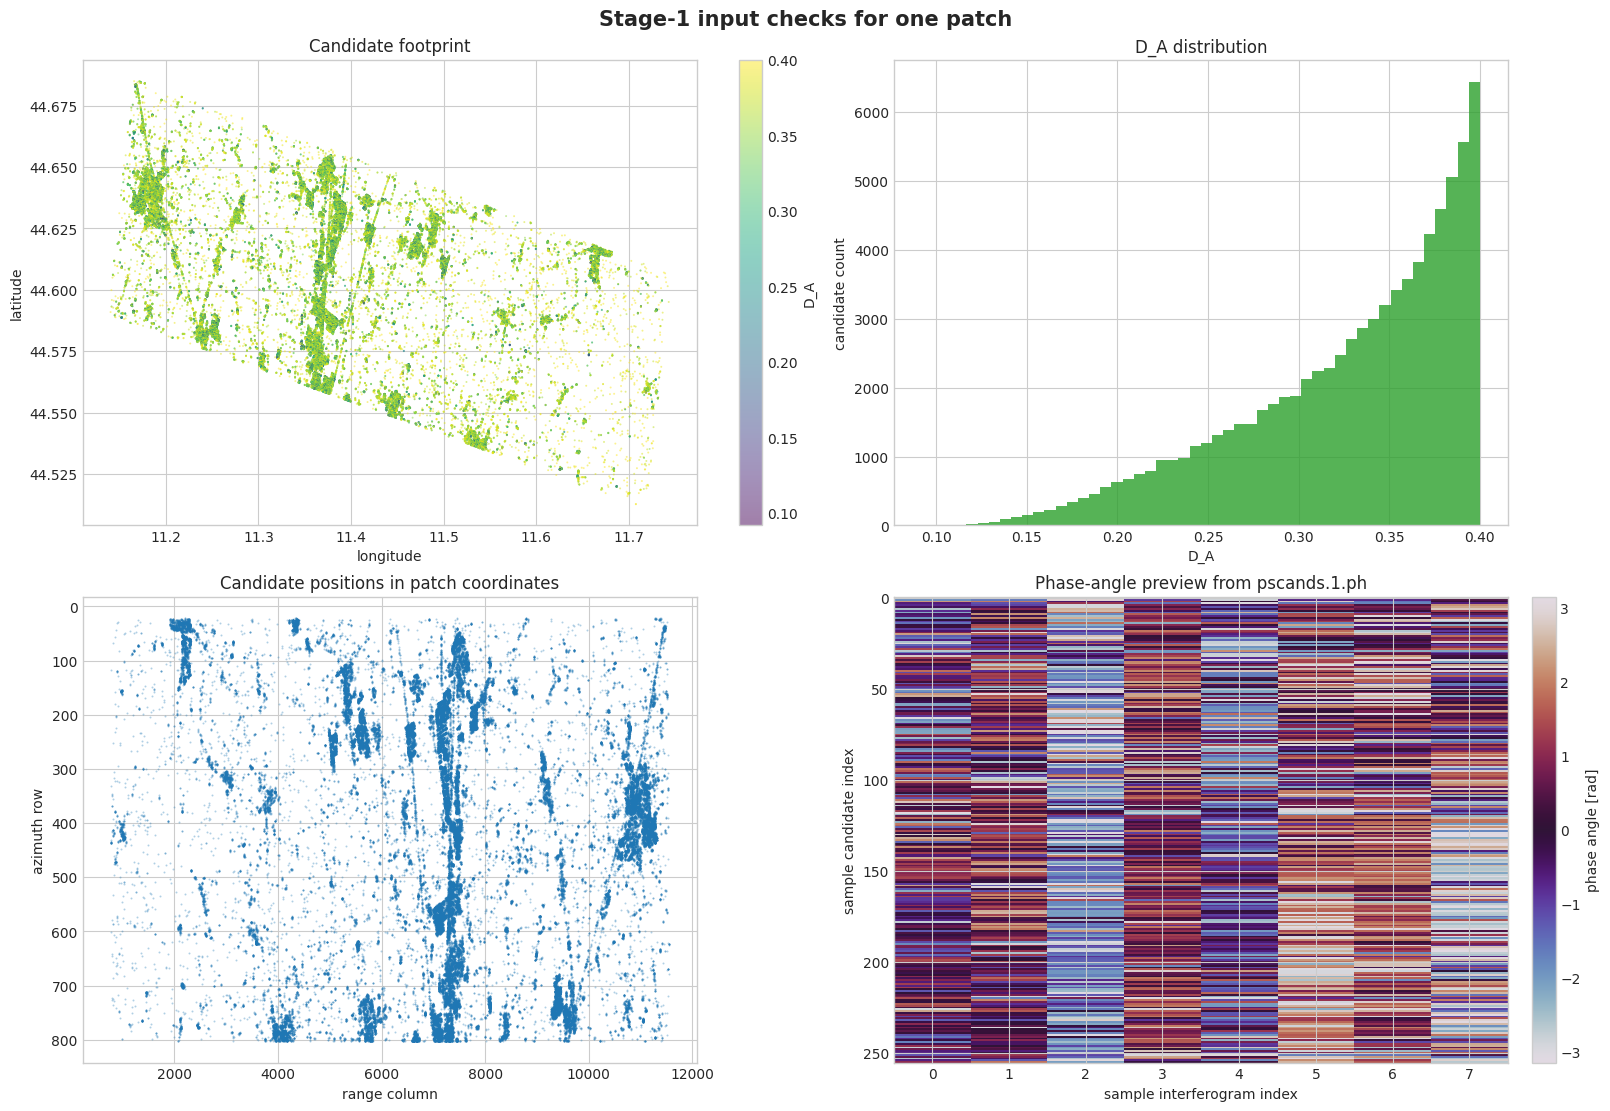

In [10]:
patch = SUMMARY['patch']
phase_preview = SUMMARY['phase_preview']
lonlat = patch['lonlat']
da = np.asarray(patch['da'], dtype=float).reshape(-1)
ij = patch['ij']

fig, axes = plt.subplots(2, 2, figsize=(16, 11), constrained_layout=True)
fig.suptitle('Stage-1 input checks for one patch', fontsize=15, fontweight='bold')

finite_da = np.isfinite(da)
if finite_da.any():
    scatter = axes[0, 0].scatter(lonlat[:, 0], lonlat[:, 1], c=da, s=2, cmap='viridis', alpha=0.5, linewidths=0)
    fig.colorbar(scatter, ax=axes[0, 0], fraction=0.046, pad=0.04, label='D_A')
else:
    axes[0, 0].scatter(lonlat[:, 0], lonlat[:, 1], s=2, color='tab:blue', alpha=0.5, linewidths=0)
axes[0, 0].set_title('Candidate footprint')
axes[0, 0].set_xlabel('longitude')
axes[0, 0].set_ylabel('latitude')

if finite_da.any():
    axes[0, 1].hist(da[finite_da], bins=50, color='tab:green', alpha=0.8)
    axes[0, 1].set_xlabel('D_A')
    axes[0, 1].set_ylabel('candidate count')
else:
    axes[0, 1].text(0.5, 0.5, 'No D_A values available in this patch', ha='center', va='center', transform=axes[0, 1].transAxes)
    axes[0, 1].set_axis_off()
axes[0, 1].set_title('D_A distribution')

axes[1, 0].scatter(ij[:, 2], ij[:, 1], s=2, c='tab:blue', alpha=0.35, linewidths=0)
axes[1, 0].set_title('Candidate positions in patch coordinates')
axes[1, 0].set_xlabel('range column')
axes[1, 0].set_ylabel('azimuth row')
axes[1, 0].invert_yaxis()

im = axes[1, 1].imshow(phase_preview['angle'], aspect='auto', cmap='twilight', interpolation='nearest')
axes[1, 1].set_title('Phase-angle preview from pscands.1.ph')
axes[1, 1].set_xlabel('sample interferogram index')
axes[1, 1].set_ylabel('sample candidate index')
fig.colorbar(im, ax=axes[1, 1], fraction=0.046, pad=0.04, label='phase angle [rad]')

plt.show()

## Optional metadata plots

These are secondary checks, but they are still useful:

- a height histogram tells you whether an optional height prior exists and looks plausible
- an acquisition timeline gives a quick view of temporal coverage

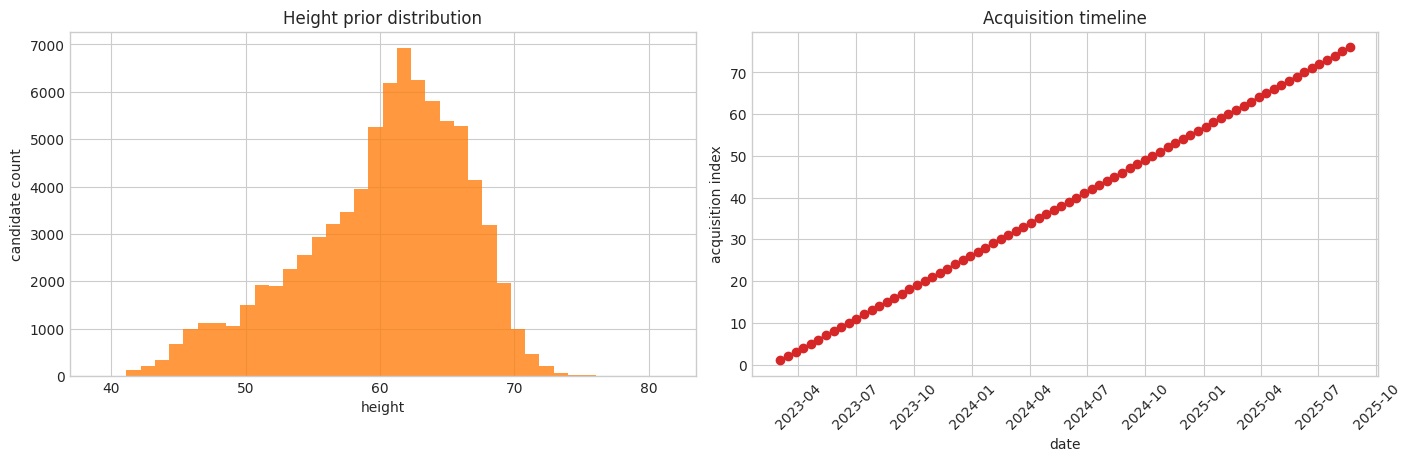

In [11]:
height_values = np.asarray(SUMMARY['height_values'], dtype=float).reshape(-1)
acquisition_plot_df = pd.DataFrame(SUMMARY['acquisition_rows'])

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), constrained_layout=True)

if height_values.size:
    axes[0].hist(height_values, bins=40, color='tab:orange', alpha=0.8)
    axes[0].set_xlabel('height')
    axes[0].set_ylabel('candidate count')
else:
    axes[0].text(0.5, 0.5, 'No pscands.1.hgt values are available for this patch', ha='center', va='center', transform=axes[0].transAxes)
    axes[0].set_axis_off()
axes[0].set_title('Height prior distribution')

if not acquisition_plot_df.empty:
    acquisition_plot_df = acquisition_plot_df.copy()
    acquisition_plot_df['date'] = pd.to_datetime(acquisition_plot_df['date'])
    axes[1].plot(acquisition_plot_df['date'], acquisition_plot_df['acquisition_index'], marker='o', linewidth=1.5, color='tab:red')
    axes[1].set_xlabel('date')
    axes[1].set_ylabel('acquisition index')
    axes[1].tick_params(axis='x', rotation=45)
else:
    axes[1].text(0.5, 0.5, 'No acquisition dates were found', ha='center', va='center', transform=axes[1].transAxes)
    axes[1].set_axis_off()
axes[1].set_title('Acquisition timeline')

plt.show()

## Useful CLI commands

The notebook API and the CLI are aligned. The same logical contracts shown above can be printed from the command line.

The two most useful commands are:

- inspect the Stage-1 contract and check one dataset
- print the logical contract for all stages

This is useful when you want a scriptable, non-notebook view of the same information.

In [12]:
stage1_cli = 'uv run pystamps describe-inputs --stage 1 --dataset <dataset> --patch PATCH_1'
all_stages_cli = 'uv run pystamps describe-inputs --stage all'
stage1_dry_run = 'uv run pystamps run --dataset <dataset> --start-step 1 --end-step 1 --dry-run'

print(stage1_cli)
print(all_stages_cli)
print(stage1_dry_run)

uv run pystamps describe-inputs --stage 1 --dataset <dataset> --patch PATCH_1
uv run pystamps describe-inputs --stage all
uv run pystamps run --dataset <dataset> --start-step 1 --end-step 1 --dry-run


## What Stage 1 writes next

Once these inputs look sensible, Stage 1 writes structured outputs for the rest of the pipeline. The most important are:

- `ps1.mat`: organized geometry, timing, and indexing metadata
- `ph1.mat`: the complex phase stack reordered to match the Stage-1 metadata
- `bp1.mat`: baseline information aligned with the phase stack
- `da1.mat` and `hgt1.mat`: optional side products when those inputs exist

The operational habit is: inspect first, then run.

## Next step

Move to `02_pystamps_stage_execution.ipynb` after you are comfortable with the Stage-1 inputs.

That notebook shows how pySTAMPS executes stages and how to validate outputs against STAMPS.